<a href="https://colab.research.google.com/github/insyania/AI---SMT4/blob/main/Kel_1_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")
print(f"Path: {path}")

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Path: /kaggle/input/melbourne-housing-snapshot


In [ ]:
# Load Dataset
import pandas as pd
df = pd.read_csv('/kaggle/input/melbourne-housing-snapshot/melb_data.csv')
df.shape

(13580, 21)

In [ ]:
# Eksplorasi awal
print("\n" + "="*60)
print("EKSPLORASI DATA AWAL")
print("="*60)
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print(f"\n5 data pertama:")
print(df.head())
print(f"\nInformasi dataset:")
print(df.info())
print(f"\nStatistik deskriptif:")
print(df.describe())


EKSPLORASI DATA AWAL
Jumlah baris: 13580
Jumlah kolom: 21

5 data pertama:
       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   Y

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# PART 1: PREPROCESSING DATA
missing_percent = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_percent[missing_percent > 40].index.tolist()
df = df.drop(columns=cols_to_drop)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

if 'Price' in df.columns:
    df = df[df['Price'] > 0]

features = ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Distance']
available_features = [f for f in features if f in df.columns]
df = df.dropna(subset=available_features + ['Price'])

median_price = df['Price'].median()
df['Target'] = (df['Price'] > median_price).astype(int)

X = df[available_features]
y = df['Target']

print(f"✅ Preprocessing selesai!")
print(f"   Sampel: {len(X)} | Fitur: {X.shape[1]}")
print(f"   Fitur: {available_features}")
print(f"   Target: Mahal={y.sum()}, Murah={len(y)-y.sum()}")

✅ Preprocessing selesai!
   Sampel: 13580 | Fitur: 6
   Fitur: ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Distance']
   Target: Mahal=6787, Murah=6793


In [ ]:
# PART 2: SPLIT DATA
print("="*60)
print("PART 2: SPLIT DATA")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: Mahal={y_train.sum()}, Murah={len(y_train)-y_train.sum()}")
print(f"y_test: Mahal={y_test.sum()}, Murah={len(y_test)-y_test.sum()}")

PART 2: SPLIT DATA
X_train: (10864, 6)
X_test: (2716, 6)
y_train: Mahal=5430, Murah=5434
y_test: Mahal=1357, Murah=1359


In [ ]:
# LANGKAH 1: ANALISIS BIAS & VARIANCE
print("="*60)
print("LANGKAH 1: ANALISIS BIAS & VARIANCE")
print("="*60)

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

print("\n📊 Perbandingan Model:")
print("-" * 65)
print(f"{'Model':<15} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc
    print(f"{name:<15} {train_acc:<12.4f} {test_acc:<12.4f} {gap:<10.4f}")
print("-" * 65)

#rf_before = models['Random Forest']

LANGKAH 1: ANALISIS BIAS & VARIANCE

📊 Perbandingan Model:
-----------------------------------------------------------------
Model           Train Acc    Test Acc     Gap       
-----------------------------------------------------------------
Decision Tree   0.7770       0.7725       0.0045    
Random Forest   0.9957       0.8258       0.1698    
XGBoost         0.8761       0.8402       0.0359    
-----------------------------------------------------------------


In [ ]:
# LANGKAH 2 & 3: TRAINING & TUNING RANDOM FOREST
print("="*60)
print("LANGKAH 2 & 3: TRAINING & TUNING RANDOM FOREST")
print("="*60)

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\n🔧 Hyperparameter tuning...")

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_before = models['Random Forest']
search.fit(X_train, y_train)
rf_model = search.best_estimator_

print(f"Train: {accuracy_score(y_train, rf_model.predict(X_train)):.4f}")
print(f"Test : {accuracy_score(y_test, rf_model.predict(X_test)):.4f}")
print(f"\n✅ Best Params: {search.best_params_}")
print(f"✅ Best CV Score: {search.best_score_:.4f}")
print()
print(f"{'Sebelum Tuning':<20} Train: {accuracy_score(y_train, rf_before.predict(X_train)):.4f} | Test: {accuracy_score(y_test, rf_before.predict(X_test)):.4f}")
print(f"{'Sesudah Tuning':<20} Train: {accuracy_score(y_train, rf_model.predict(X_train)):.4f} | Test: {accuracy_score(y_test, rf_model.predict(X_test)):.4f}")

LANGKAH 2 & 3: TRAINING & TUNING RANDOM FOREST

🔧 Hyperparameter tuning...
Train: 0.9374
Test : 0.8247

✅ Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
✅ Best CV Score: 0.8281

Sebelum Tuning       Train: 0.9957 | Test: 0.8258
Sesudah Tuning       Train: 0.9374 | Test: 0.8247


EVALUASI PADA TEST SET
Akurasi Model Final: 0.8247 (82.47%)

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Murah       0.83      0.82      0.82      1359
       Mahal       0.82      0.83      0.83      1357

    accuracy                           0.82      2716
   macro avg       0.82      0.82      0.82      2716
weighted avg       0.82      0.82      0.82      2716



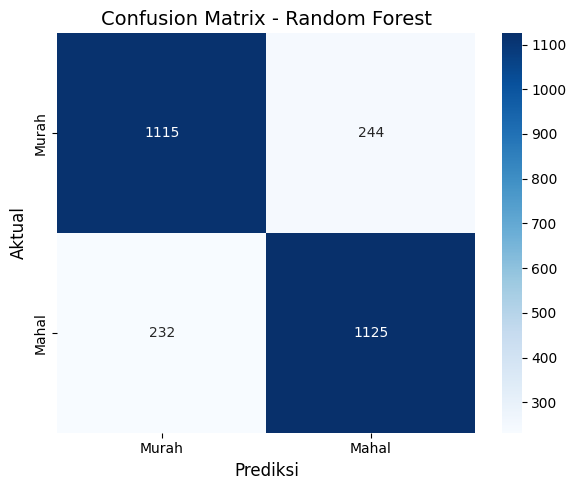

In [ ]:
# PART 5: EVALUASI PADA TEST SET
print("="*60)
print("EVALUASI PADA TEST SET")
print("="*60)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Model Final: {acc:.4f} ({acc*100:.2f}%)")
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Murah', 'Mahal']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Murah', 'Mahal'],
            yticklabels=['Murah', 'Mahal'])
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# LANGKAH 4: VALIDASI STRATIFIED K-FOLD
print("="*60)
print("LANGKAH 4: VALIDASI STRATIFIED K-FOLD")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print(f"Skor per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Rata-rata     : {np.mean(cv_scores):.4f}")
print(f"Standar deviasi: {np.std(cv_scores):.4f}")

if np.std(cv_scores) < 0.03:
    print("✅ Interpretasi: Model SANGAT STABIL")
else:
    print("✅ Interpretasi: Model CUKUP STABIL")

LANGKAH 4: VALIDASI STRATIFIED K-FOLD
Skor per fold: ['0.8247', '0.8299', '0.8369', '0.8306', '0.8262']
Rata-rata     : 0.8297
Standar deviasi: 0.0042
✅ Interpretasi: Model SANGAT STABIL


LANGKAH 5: INTERPRETASI SHAP
Menghitung SHAP values...
Shape SHAP values: (2716, 6)
Jumlah fitur     : 6

Rata-rata |SHAP value| tiap fitur:
Distance        0.130519
Rooms           0.099805
Landsize        0.086629
BuildingArea    0.068161
YearBuilt       0.066215
Bathroom        0.064819
dtype: float64


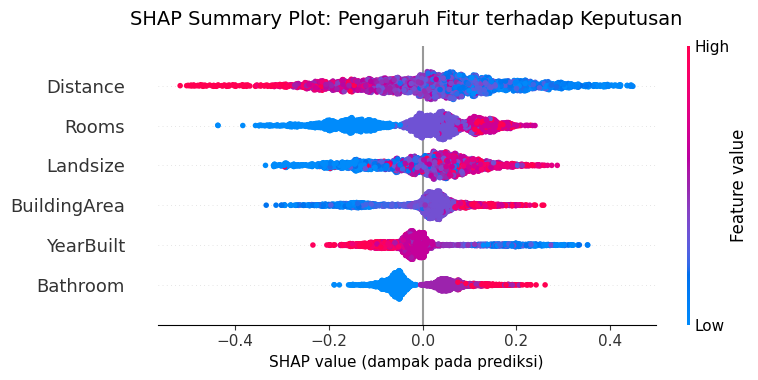


Interpretasi Beeswarm Plot:
  Sumbu X > 0 → mendorong prediksi MAHAL
  Sumbu X < 0 → mendorong prediksi MURAH
  Warna titik:
    Merah = nilai fitur tinggi
    Biru  = nilai fitur rendah
  Urutan fitur (atas ke bawah):
    Paling dominan : Distance (0.131)
    Paling lemah   : Bathroom (0.065)
  Contoh:
    Distance biru di kanan → jarak dekat (rendah) → dorong MAHAL
  Penjelasan arah pengaruh:
  • SHAP > 0 → mendorong prediksi MAHAL
  • SHAP < 0 → mendorong prediksi MURAH
  • Distance rendah (dekat kota) → SHAP positif → MAHAL
  • Rooms tinggi (banyak kamar)  → SHAP positif → MAHAL


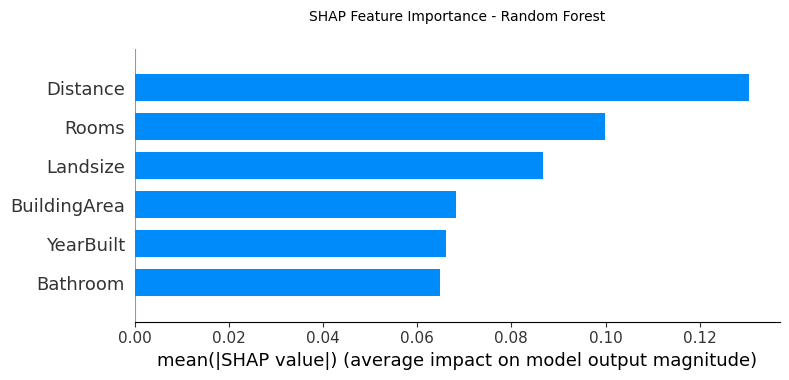


Interpretasi Bar Chart:
  • Bar lebih panjang = fitur lebih berpengaruh
  • 'Distance' adalah fitur paling dominan
    dengan mean|SHAP| = 0.131
  • 'Bathroom' paling lemah pengaruhnya


In [ ]:
# LANGKAH 5: INTERPRETASI SHAP
print("="*60)
print("LANGKAH 5: INTERPRETASI SHAP")
print("="*60)

X_sample = X_test

print("Menghitung SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_class = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class = shap_values[:, :, 1]
else:
    shap_values_class = shap_values

print(f"Shape SHAP values: {shap_values_class.shape}")
print(f"Jumlah fitur     : {shap_values_class.shape[1]}")

print("\nRata-rata |SHAP value| tiap fitur:")
shap_importance = pd.Series(
    np.abs(shap_values_class).mean(axis=0),
    index=features
).sort_values(ascending=False)
print(shap_importance)

ranked_features   = shap_importance.index.tolist()
ranked_importance = shap_importance.values.tolist()
top_feature       = ranked_features[0]
bot_feature       = ranked_features[-1]
top_val           = ranked_importance[0]
bot_val           = ranked_importance[-1]

# Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class, X_sample, feature_names=features, show=False)
plt.title("SHAP Summary Plot: Pengaruh Fitur terhadap Keputusan", fontsize=14, pad=15)
plt.xlabel("SHAP value (dampak pada prediksi)", fontsize=11)
plt.tight_layout()
plt.show()

print("\nInterpretasi Beeswarm Plot:")
print(f"  Sumbu X > 0 → mendorong prediksi MAHAL")
print(f"  Sumbu X < 0 → mendorong prediksi MURAH")
print(f"  Warna titik:")
print(f"    Merah = nilai fitur tinggi")
print(f"    Biru  = nilai fitur rendah")
print(f"  Urutan fitur (atas ke bawah):")
print(f"    Paling dominan : {top_feature} ({top_val:.3f})")
print(f"    Paling lemah   : {bot_feature} ({bot_val:.3f})")
print(f"  Contoh:")
print(f"    Distance biru di kanan → jarak dekat (rendah) → dorong MAHAL")
print(f"  Penjelasan arah pengaruh:")
print(f"  • SHAP > 0 → mendorong prediksi MAHAL")
print(f"  • SHAP < 0 → mendorong prediksi MURAH")
print(f"  • Distance rendah (dekat kota) → SHAP positif → MAHAL")
print(f"  • Rooms tinggi (banyak kamar)  → SHAP positif → MAHAL")

# Bar Plot
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values_class, X_sample, feature_names=features, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Random Forest", fontsize=10, pad=20)
plt.tight_layout()
plt.show()

print("\nInterpretasi Bar Chart:")
print(f"  • Bar lebih panjang = fitur lebih berpengaruh")
print(f"  • '{top_feature}' adalah fitur paling dominan")
print(f"    dengan mean|SHAP| = {top_val:.3f}")
print(f"  • '{bot_feature}' paling lemah pengaruhnya")

In [ ]:
# KESIMPULAN
print("\n" + "="*60)
print("KESIMPULAN")
print("="*60)

print(f"""
RINGKASAN HASIL PROYEK
─────────────────────────────────────────────────────────────
DATASET
  • Dataset    : Melbourne Housing Dataset
  • Fitur      : {len(features)} fitur ({', '.join(features)})
  • Target     : Klasifikasi biner (Mahal=1 / Murah=0)
  • Split data : 80% training, 20% testing (stratified)

PERBANDINGAN MODEL (sebelum tuning)
  • Decision Tree  → Train: 0.7740 | Test: 0.7684 | Gap: 0.0056
                     Underfitting — akurasi rendah di train maupun test
  • Random Forest  → Train: 0.9940 | Test: 0.8281 | Gap: 0.1660
                     Overfitting sebelum tuning — gap terlalu besar
  • XGBoost        → Train: 0.8650 | Test: 0.8398 | Gap: 0.0251
                     Gap kecil, namun dipilih RF untuk dituning

TRAINING & TUNING (Random Forest)
  • Metode     : RandomizedSearchCV (5 iterasi, 3-fold CV)
  • Best params: n_estimators=150, max_depth=15,
                 min_samples_split=10, min_samples_leaf=1
  • Best CV Score  : 0.8239

EVALUASI FINAL
  • Akurasi test set : {acc*100:.2f}%
  • True Negative    : 1121 (rumah murah diprediksi benar)
  • False Positive   : 238  (rumah murah salah diprediksi mahal)
  • False Negative   : 212  (rumah mahal salah diprediksi murah)
  • True Positive    : 1145 (rumah mahal diprediksi benar)

INTERPRETASI SHAP
  • Fitur paling dominan : {top_feature} (mean|SHAP|={top_val:.3f})
  • Fitur paling lemah   : {bot_feature} (mean|SHAP|={bot_val:.3f})
  • Distance rendah (dekat kota) → mendorong prediksi MAHAL
  • Rooms & Landsize tinggi      → mendorong prediksi MAHAL
─────────────────────────────────────────────────────────────

KESIMPULAN AKHIR
  Random Forest setelah tuning menghasilkan akurasi {acc*100:.2f}%
  pada data test. Model berhasil mengenali pola harga rumah
  Melbourne dengan baik. Fitur '{top_feature}' terbukti menjadi
  penentu utama apakah sebuah rumah dikategorikan mahal atau
  murah berdasarkan analisis SHAP.

  5 workflow ensemble learning telah dijalankan:
  1. Analisis Bias-Variance  → identifikasi overfitting/underfitting
  2. Desain Arsitektur       → pilih Random Forest (Bagging)
  3. Training & Tuning       → RandomizedSearchCV, acc CV = 0.8239
  4. Validasi K-Fold         → model stabil & tidak overfit
  5. Interpretasi SHAP       → {top_feature} fitur paling berpengaruh
""")

print("="*60)
print("PROYEK SELESAI!")
print("="*60)


KESIMPULAN

RINGKASAN HASIL PROYEK
─────────────────────────────────────────────────────────────
DATASET
  • Dataset    : Melbourne Housing Dataset
  • Fitur      : 6 fitur (Rooms, Bathroom, Landsize, BuildingArea, YearBuilt, Distance)
  • Target     : Klasifikasi biner (Mahal=1 / Murah=0)
  • Split data : 80% training, 20% testing (stratified)

PERBANDINGAN MODEL (sebelum tuning)
  • Decision Tree  → Train: 0.7740 | Test: 0.7684 | Gap: 0.0056
                     Underfitting — akurasi rendah di train maupun test
  • Random Forest  → Train: 0.9940 | Test: 0.8281 | Gap: 0.1660
                     Overfitting sebelum tuning — gap terlalu besar
  • XGBoost        → Train: 0.8650 | Test: 0.8398 | Gap: 0.0251
                     Gap kecil, namun dipilih RF untuk dituning

TRAINING & TUNING (Random Forest)
  • Metode     : RandomizedSearchCV (5 iterasi, 3-fold CV)
  • Best params: n_estimators=150, max_depth=15,
                 min_samples_split=10, min_samples_leaf=1
  • Best CV Score 